[BATCH] Converged early at iteration: 722

Batch Gradient Results
Execution Time: 0.08748269081115723 seconds
Optimal theta: [ 2.05781435e+01  5.99421332e-01 -1.20439309e+00  3.02541758e+00
 -2.62943985e+00  3.63516456e+00 -1.40022106e-02  2.57917361e+00
  4.00366455e-01]
Final cost: 7.035133292127452
Test Mean Squared Error: 3.7333304841157324

Stochastic Gradient Results
Execution Time: 3.4961133003234863 seconds
Optimal theta: [21.81647267 -6.62726969 -3.38909498  0.72535323 -3.67413909  7.51692901
 -0.18996055  2.68903563  0.50349337]
Final cost: 4.483235701146384
Test Mean Squared Error: 2.9221814318035295

Normal Equation Results
Execution Time: 0.05692744255065918 seconds
Optimal theta: [ 2.21592652e+01 -1.96192056e+00 -1.16708214e+00  2.54338804e+00
 -1.59700079e+00  7.55557214e+00  7.95665280e-03  2.72561700e+00
  4.17057966e-01]
Test Mean Squared Error: 3.050898789939493

Locally Weighted Results
Execution Time: 4.130319595336914 seconds
Optimal theta: [ 3.90717461e+01  1.734

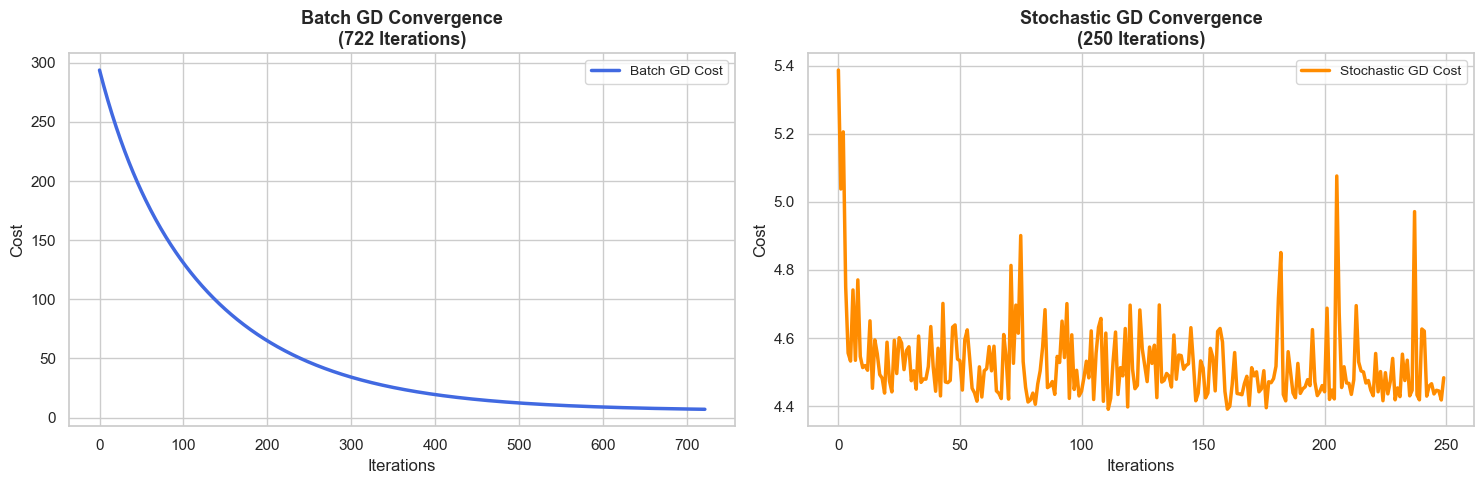

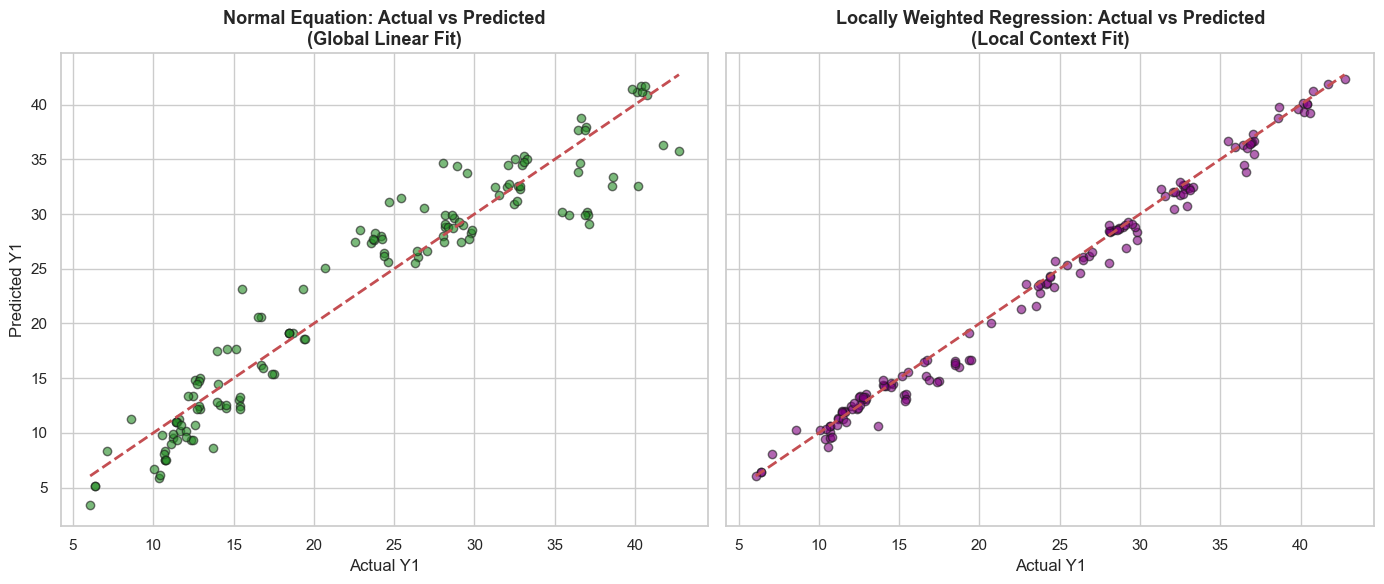

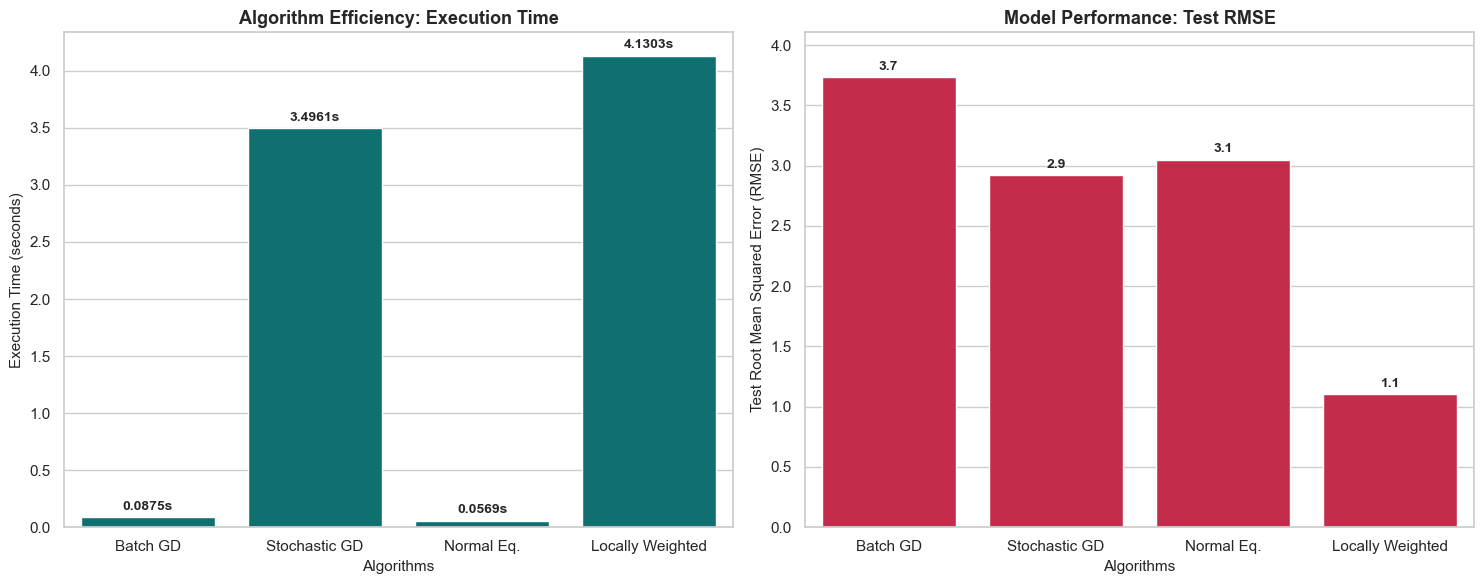

In [1]:
import pandas as pd
import numpy as np
import time as t
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv('Training_dataset.csv')
data_test = pd.read_csv('test_dataset.csv')

X = data[['X1', 'X2','X3','X4','X5','X6','X7','X8']].values
X_t = data_test[['X1', 'X2','X3','X4','X5','X6','X7','X8']].values
y = data['Y1'].values 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_mean = X_train.mean(axis=0)
X_std = X_train.std(axis=0)

X_train_norm = (X_train - X_mean) / X_std
X_test_norm = (X_test - X_mean) / X_std
X_t_norm = (X_t - X_mean) / X_std

m_train = len(y_train)
m_test = len(y_test)
m_t = len(data_test)

X_train_b = np.c_[np.ones((m_train, 1)), X_train_norm] 
X_test_b = np.c_[np.ones((m_test, 1)), X_test_norm]
X_t_b = np.c_[np.ones((m_t, 1)), X_t_norm]

def normal_equation(X_train_b, y_train):
    theta = np.linalg.inv(X_train_b.T.dot(X_train_b)).dot(X_train_b.T).dot(y_train)
    return theta

def compute_weights(X_train_b, X_q, tau):
    m = len(X_train_b)
    W = np.zeros((m, m))
    
    for i in range(m):
        diff = X_train_b[i] - X_q
        W[i, i] = np.exp(np.sum(diff ** 2) / (-2.0 * tau ** 2))
    return W

def local_normal_equation(X_train_b, y_train, W):
    XT_W = X_train_b.T.dot(W)
    best_theta = np.linalg.pinv(XT_W.dot(X_train_b)).dot(XT_W).dot(y_train)
    return best_theta
    
def compute_cost(X_train_b, y_train, theta):
    m = len(y_train)
    predictions = X_train_b.dot(theta) 
    cost = (1/(2*m)) * np.sum((predictions - y_train) ** 2)
    return cost

def gradient_descent(X, y, theta, alpha, max_iterations, method="batch"):
    m = len(y)
    cost_history = []
    actual_iterations = 0
    tol = 1e-2

    for i in range(max_iterations):
        actual_iterations += 1

        if method == "batch":
            predictions = X.dot(theta)
            gradients = (1 / m) * X.T.dot(predictions - y)
            theta = theta - alpha * gradients

        elif method == "stochastic":
            permutation = np.random.permutation(m)
            X_shuffled = X[permutation]
            y_shuffled = y[permutation]

            for j in range(m):
                xi = X_shuffled[j : j + 1]
                yi = y_shuffled[j : j + 1]

                prediction = xi.dot(theta)
                gradient = xi.T.dot(prediction - yi)
                theta = theta - alpha * gradient

        current_cost = compute_cost(X, y, theta)
        cost_history.append(current_cost)

        if method == "batch" and i > 0:
            cost_difference = abs(cost_history[-2] - cost_history[-1])
            if cost_difference < tol:
                print(
                    f"[{method.upper()}] Converged early at iteration: {actual_iterations}"
                )
                break

    return theta, np.array(cost_history), actual_iterations
    
def display_results(title,end,start,theta,cost_history,mse,type='gradient_descent'):
    if type == 'gradient_descent':
        print(f"\n{title}")
        print(f"Execution Time: {end-start} seconds")
        print(f"Optimal theta: {theta}")
        print(f"Final cost: {cost_history[-1]}")
        print(f"Test Mean Squared Error: {mse}")
    else:
        print(f"\n{title}")
        print(f"Execution Time: {end-start} seconds")
        print(f"Optimal theta: {theta}")
        print(f"Test Mean Squared Error: {mse}")
        
tau = 0.5
theta = np.zeros(X_train_b.shape[1])

start_1 = t.time()
best_theta_1, cost_history_1, actual_iterations_1 = gradient_descent(X_train_b, y_train, theta, 0.00365, 2500)
end_1 = t.time()

start_2 = t.time()
best_theta_2, cost_history_2, actual_iterations_2 = gradient_descent(X_train_b, y_train, theta, 0.01, 250,'stochastic')
end_2 = t.time()

start_3 = t.time()
best_theta_3 = normal_equation(X_train_b, y_train)
end_3 = t.time()

predicted_Y1_4 = np.zeros(m_test)
start_4 = t.time()
for j in range(m_test):
    X_q = X_test_b[j]
    
    W = compute_weights(X_train_b, X_q, tau)
    
    best_theta_4 = local_normal_equation(X_train_b, y_train, W)
    
    predicted_Y1_4[j] = X_q.dot(best_theta_4)
end_4 = t.time()

predicted_Y1_1 = X_test_b.dot(best_theta_1)
rmse_1 = np.sqrt(np.mean((predicted_Y1_1 - y_test)**2))

predicted_Y1_2 = X_test_b.dot(best_theta_2)
rmse_2 = np.sqrt(np.mean((predicted_Y1_2 - y_test)**2))

predicted_Y1_3 = X_test_b.dot(best_theta_3)
rmse_3 = np.sqrt(np.mean((predicted_Y1_3 - y_test)**2))

rmse_4 = np.sqrt(np.mean((predicted_Y1_4 - y_test) ** 2))

display_results("Batch Gradient Results",end_1,start_1,best_theta_1,cost_history_1,rmse_1)
display_results("Stochastic Gradient Results",end_2,start_2,best_theta_2,cost_history_2,rmse_2)
display_results("Normal Equation Results",end_3,start_3,best_theta_3,0,rmse_3,'normal')
display_results("Locally Weighted Results",end_4,start_4,best_theta_4,0,rmse_4,'lwr')

predicted_Y1= np.zeros(m_t)
for j in range(m_t):
    X_q = X_t_b[j]
    
    W = compute_weights(X_train_b, X_q, tau=0.5)
    
    local_theta = local_normal_equation(X_train_b, y_train, W)
    
    predicted_Y1[j] = X_q.dot(local_theta)
    
submission = pd.DataFrame()
predicted = pd.DataFrame()

predicted_Y1_rounded = np.round(predicted_Y1, 2)
if 'ID' in data_test.columns:
    submission['ID'] = data_test['ID']
else:
    submission['ID'] = data_test.index

submission['Heating_Load'] = predicted_Y1_rounded
predicted['HeatingLoad'] = predicted_Y1_4
predicted['Y1'] = y_test
predicted.to_csv('trials.csv', index=False)
submission.to_csv('1703871685_submission.csv', index=False)
# print("\nPredictions successfully saved to '1703871685_submission.csv'!")

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(cost_history_1, color='royalblue', linewidth=2.5, label='Batch GD Cost')
axes[0].set_xlabel('Iterations', fontsize=12)
axes[0].set_ylabel('Cost', fontsize=12)
axes[0].set_title(f'Batch GD Convergence\n({actual_iterations_1} Iterations)', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)

axes[1].plot(cost_history_2, color='darkorange', linewidth=2.5, label='Stochastic GD Cost')
axes[1].set_xlabel('Iterations', fontsize=12)
axes[1].set_ylabel('Cost', fontsize=12)
axes[1].set_title(f'Stochastic GD Convergence\n({actual_iterations_2} Iterations)', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

axes[0].scatter(y_test, predicted_Y1_3, alpha=0.6, color='forestgreen', edgecolors='k')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Y1', fontsize=12)
axes[0].set_ylabel('Predicted Y1', fontsize=12)
axes[0].set_title('Normal Equation: Actual vs Predicted\n(Global Linear Fit)', fontsize=13, fontweight='bold')

axes[1].scatter(y_test, predicted_Y1_4, alpha=0.6, color='purple', edgecolors='k')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual Y1', fontsize=12)
axes[1].set_title('Locally Weighted Regression: Actual vs Predicted\n(Local Context Fit)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

algorithms = ['Batch GD', 'Stochastic GD', 'Normal Eq.', 'Locally Weighted']
execution_times = [end_1-start_1, end_2-start_2, end_3-start_3, end_4-start_4]
rmses = [rmse_1, rmse_2, rmse_3, rmse_4]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

teal_map = {algo: "teal" for algo in algorithms}
crimson_map = {algo: "crimson" for algo in algorithms}

sns.barplot(x=algorithms, y=execution_times, ax=axes[0], palette=teal_map, hue=algorithms, legend=False)
axes[0].set_title('Algorithm Efficiency: Execution Time', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Algorithms', fontsize=11)
axes[0].set_ylabel('Execution Time (seconds)', fontsize=11)

for bar in axes[0].patches:
    yval = bar.get_height()
    if yval > 0:
        axes[0].text(bar.get_x() + bar.get_width()/2, yval + (max(execution_times)*0.01), 
                     f"{yval:.4f}s", ha='center', va='bottom', fontsize=10, fontweight='bold')

sns.barplot(x=algorithms, y=rmses, ax=axes[1], palette=crimson_map, hue=algorithms, legend=False)
axes[1].set_title('Model Performance: Test RMSE', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Algorithms', fontsize=11)
axes[1].set_ylabel('Test Root Mean Squared Error (RMSE)', fontsize=11)
axes[1].set_ylim(0, max(rmses) * 1.1)

for bar in axes[1].patches:
    yval = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, yval + (max(rmses)*0.01), 
                 f"{yval:.1f}", ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()